# Lesson 2: Analytics and Diversity (FlashBackGraph)

In Lesson 1 you learned to build a `FlashBackGraph`, score sequences
with `pgen()`, simulate, and run the FlashBack Anomaly Score. This
lesson zooms out to *distributional* properties of the graph.

By the end you'll be able to:

1. State *why* FlashBack analytics are closed-form, and verify the
   exactness empirically (three Hill-family entry points must return
   the same number)
2. Use `hill_number`, `hill_numbers`, `hill_curve`, and
   `diversity_profile` for diversity reporting
3. Read the closed-form moments and the `power_sum` building block
4. Compare two repertoires distributionally (`jensen_shannon_divergence`)
   and structurally (Jaccard over graph nodes)
5. Build a quick per-sequence surprise metric from `pgen()` directly
6. Recognize where `LZGraph` covers ground that `FlashBackGraph`
   does not (occupancy predictions, sharing spectrum, perplexity)
   and where `FlashBackGraph` is the faster choice

> **The headline of this lesson.** Where the LZGraph analytics module
> leans on Monte Carlo for anything beyond `path_count`, the
> FlashBackGraph analytics module is *deterministic and exact*
> end-to-end. The same forward DP that produces the moments produces
> the Hill numbers, the entropy, and the power sums. They are all
> internally consistent. The downside: a few high-level helpers
> available on `LZGraph` (occupancy, sharing spectrum, perplexity,
> `k_diversity`) are not implemented on `FlashBackGraph`. We cover
> the ones that exist and note where to use the LZGraph track for
> the others.


In [1]:
from LZGraphs import FlashBackGraph, LZGraph, jensen_shannon_divergence
import numpy as np
import csv
import time
import matplotlib.pyplot as plt


## Setup: load data and build the graph

The same 5,000 amino-acid CDR3 repertoire used in Lesson 1 and across
both tracks. `FlashBackGraph` does not take V/J gene calls, so we load
just the sequences.


In [2]:
sequences = []
with open('../data/ExampleData3.csv') as f:
    for row in csv.DictReader(f):
        sequences.append(row['cdr3_amino_acid'])

graph = FlashBackGraph(sequences)
print(graph)
print(f'path_count: {graph.path_count:,.0f}')


FlashBackGraph(nodes=2826, edges=11899)
path_count: 93,288,322


## 1. Why FlashBack analytics are closed-form

The FlashBack tokenization is **Markovian** by construction: each
transition in the graph depends only on the current token, not on
where you came from before. That property is what makes everything
in this notebook work without sampling.

For a Markovian DAG, the probability mass at each node can be
propagated in a single forward sweep in topological order. Hill
numbers, entropy, power sums, and the moments of the log-PGEN
distribution all decompose into sums over this single sweep with the
right per-node functional. So a forward pass that costs
$O(\text{edges})$ gives you *all* of them at once, exactly.

Contrast that with LZGraph: each LZ76 token extends the longest
previously-seen prefix, so the dependency graph is non-Markovian and
the forward DP recursions don't close. LZGraph falls back to
importance-weighted Monte Carlo for those quantities.

The rest of this lesson treats "exact" as the default and flags every
estimator we use as such.


## 2. Hill diversity numbers (and the exactness check)

The Hill numbers $D(\alpha) = (\sum_i p_i^\alpha)^{1/(1-\alpha)}$
unify a whole family of diversity indices. On `LZGraph` the three
entry points (`hill_number`, `hill_numbers`, `hill_curve`) disagree
with each other because each uses a different MC seed and sampling
strategy. On `FlashBackGraph` they must all return *exactly* the same
number for a given $\alpha$, because they all reduce to the same
forward-DP computation.


In [3]:
# Per-α scalar values
print(f'D(0) richness: {graph.hill_number(0):,.1f}')
print(f'D(1) Shannon:  {graph.hill_number(1):,.1f}')
print(f'D(2) Simpson:  {graph.hill_number(2):,.1f}')


D(0) richness: 93,288,322.0
D(1) Shannon:  1,436,197.6
D(2) Simpson:  124,498.5


In [4]:
# Exactness check: D(0) from three different entry points
d0_single  = graph.hill_number(0)
d0_batch   = graph.hill_numbers([0])[0]
d0_curve   = graph.hill_curve()['values'][0]
d0_path    = graph.path_count

print(f'hill_number(0):       {d0_single:,.1f}')
print(f'hill_numbers([0])[0]: {d0_batch:,.1f}')
print(f'hill_curve()[0]:      {d0_curve:,.1f}')
print(f'path_count:           {d0_path:,.1f}')

# Exact agreement (modulo float):
print()
print(f'Exact match across all four:  '
      f'{d0_single == d0_batch == d0_curve == d0_path}')


hill_number(0):       93,288,322.0
hill_numbers([0])[0]: 93,288,322.0
hill_curve()[0]:      93,288,322.0
path_count:           93,288,322.0

Exact match across all four:  True


All four numbers are *identical*. That's the closed-form story in
one cell. On the LZGraph version of this same demo, the same four
numbers spread across an order of magnitude (168B vs 855B vs 1.48T)
because each path through the analytics module uses its own MC seed.


## 3. The diversity profile: $D(\alpha)$ as a curve

`hill_curve()` returns $D(\alpha)$ on a default range of orders. Plot
it in log-y form to read the shape of the distribution: a steep drop
from $D(0)$ to $D(\infty)$ indicates a dominance-heavy distribution;
a flatter curve indicates near-uniform mass.


In [5]:
curve = graph.hill_curve()
print('Order  D(order)')
for o, d in zip(curve['orders'], curve['values']):
    print(f'  {o:5.2f}  {d:.3e}')


Order  D(order)
   0.00  9.329e+07
   0.25  2.556e+07
   0.50  8.755e+06
   0.75  3.409e+06
   1.00  1.436e+06
   1.50  3.386e+05
   2.00  1.245e+05
   2.50  6.405e+04
   3.00  4.024e+04
   4.00  2.152e+04
   5.00  1.406e+04
  10.00  5.395e+03


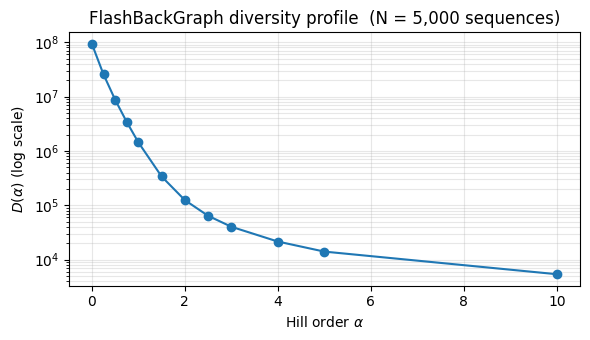

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(curve['orders'], curve['values'], 'o-')
ax.set_xlabel(r'Hill order $\alpha$')
ax.set_ylabel(r'$D(\alpha)$ (log scale)')
ax.set_title(f'FlashBackGraph diversity profile  '
             f'(N = {len(sequences):,d} sequences)')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Summary statistics: `diversity_profile()`

`diversity_profile()` returns four key quantities in one dict:
entropy in nats, entropy in bits, effective diversity ($\exp(H)$),
and uniformity ($D(1)/D(0)$). All four are exact.


In [7]:
dp = graph.diversity_profile()
print(f'Entropy (nats):      {dp["entropy_nats"]:.4f}')
print(f'Entropy (bits):      {dp["entropy_bits"]:.4f}')
print(f'Effective diversity: {dp["effective_diversity"]:,.1f}')
print(f'Uniformity:          {dp["uniformity"]:.4f}')


Entropy (nats):      14.1775
Entropy (bits):      20.4538
Effective diversity: 1,436,197.6
Uniformity:          0.0154


### Two identities the closed-form solver guarantees

Because the same forward DP produces the moments, the entropy, and
the Hill numbers, several relationships hold *exactly* (not
"approximately"):

- `entropy_nats == -pgen_moments()['mean']`
- `effective_diversity == exp(entropy_nats) == hill_number(1)`

Run them side-by-side to see the exactness:


In [8]:
import math

m = graph.pgen_moments()

assert math.isclose(dp['entropy_nats'], -m['mean'], rel_tol=1e-12), 'entropy != -E[log P]'
assert math.isclose(dp['effective_diversity'], math.exp(dp['entropy_nats']), rel_tol=1e-12)
assert math.isclose(dp['effective_diversity'], graph.hill_number(1), rel_tol=1e-12)

print('entropy_nats         =', dp['entropy_nats'])
print('-pgen_moments[mean]  =', -m['mean'])
print('exp(entropy_nats)    =', math.exp(dp['entropy_nats']))
print('hill_number(1)       =', graph.hill_number(1))
print('effective_diversity  =', dp['effective_diversity'])
print()
print('All asserts above passed: the identities hold exactly.')


entropy_nats         = 14.177509611059525
-pgen_moments[mean]  = 14.177509611059525
exp(entropy_nats)    = 1436197.5820173975
hill_number(1)       = 1436197.5820173975
effective_diversity  = 1436197.5820173975

All asserts above passed: the identities hold exactly.


## 5. The closed-form log-PGEN moments

`pgen_moments()` returns the first four central moments of the
log-PGEN distribution, plus the total absorbed mass. All deterministic
from the single forward DP.


In [9]:
m = graph.pgen_moments()
print(f'mean log P:  {m["mean"]:.4f}')
print(f'std:         {m["std"]:.4f}')
print(f'skewness:    {m["skewness"]:.4f}')
print(f'kurtosis:    {m["kurtosis"]:.4f}')
print(f'total mass:  {m["total_mass"]:.10f}')


mean log P:  -14.1775
std:         2.5686
skewness:    -0.2437
kurtosis:    -0.1548
total mass:  1.0000000000


Notice `total_mass` is exactly `1.0` (modulo floating-point noise) on
a FlashBack graph. The forward DP gives a *proper* distribution by
construction. On a typical LZGraph built from real data, the equivalent
quantity is `~0.97` (a few percent of mass leaks at non-terminal dead
ends; see Lesson 1, Section 7 in the LZGraph track for why).


> **What about `pgen_distribution()`?** On `LZGraph` this builds an
> analytical Gaussian-mixture approximation of the log-PGEN
> distribution. The same method exists on `FlashBackGraph` but the
> underlying analytical-mixture construction is not yet implemented
> for FB graphs (`graph.pgen_distribution()` raises a `RuntimeError`).
> For the FB workflow, `pgen_moments()` gives you the closed-form
> first four moments, and you can build an empirical distribution by
> calling `graph.pgen()` over a list of sequences.


## 6. `power_sum`: the building block

The Hill formula is built out of *power sums*: the quantity
$P(\alpha) = \sum_s p_s^\alpha$. FlashBackGraph exposes this
directly as `power_sum(α)`. The closed-form Hill numbers are just
$D(\alpha) = P(\alpha)^{1/(1-\alpha)}$.

This is useful when you need raw power sums for downstream
computations (e.g. Renyi entropy variants, custom diversity indices)
that aren't packaged as their own method. Verify the identity:


In [10]:
for alpha in [0.5, 2.0, 3.0, 5.0]:
    p = graph.power_sum(alpha)
    h_direct = graph.hill_number(alpha)
    h_from_p = p ** (1.0 / (1.0 - alpha))
    print(f'α={alpha:4.1f}  power_sum={p:.3e}  '
          f'hill={h_direct:.3e}  from_power_sum={h_from_p:.3e}  '
          f'match={math.isclose(h_direct, h_from_p, rel_tol=1e-10)}')


α= 0.5  power_sum=2.959e+03  hill=8.755e+06  from_power_sum=8.755e+06  match=True
α= 2.0  power_sum=8.032e-06  hill=1.245e+05  from_power_sum=1.245e+05  match=True
α= 3.0  power_sum=6.175e-10  hill=4.024e+04  from_power_sum=4.024e+04  match=True
α= 5.0  power_sum=2.560e-17  hill=1.406e+04  from_power_sum=1.406e+04  match=True


## 7. Comparing two repertoires

The two cross-repertoire comparisons available on `FlashBackGraph`
match the LZGraph track:

- **Jensen-Shannon divergence** computed in nats, range
  $[0, \ln 2 \approx 0.693]$
- **Jaccard index** over nodes / edges via the `&` operator

Both work on a pair of `FlashBackGraph` instances (do not mix one of
each family).


In [11]:
# Split into two halves and compare
g1 = FlashBackGraph(sequences[:2500])
g2 = FlashBackGraph(sequences[2500:])

jsd_diff = jensen_shannon_divergence(g1, g2)
jsd_self = jensen_shannon_divergence(g1, g1)
print(f'JSD(half1, half2): {jsd_diff:.6f}')
print(f'JSD(half1, half1): {jsd_self:.6f}  (sanity check, should be 0.0)')


JSD(half1, half2): 0.034442
JSD(half1, half1): 0.000000  (sanity check, should be 0.0)


In [12]:
# Structural overlap via intersection
inter = g1 & g2
s1, s2, si = g1.summary(), g2.summary(), inter.summary()
jaccard_nodes = si['n_nodes'] / (s1['n_nodes'] + s2['n_nodes'] - si['n_nodes'])
jaccard_edges = si['n_edges'] / (s1['n_edges'] + s2['n_edges'] - si['n_edges'])
print(f'half1 nodes={s1["n_nodes"]:,d}  half2 nodes={s2["n_nodes"]:,d}')
print(f'shared nodes={si["n_nodes"]:,d}  shared edges={si["n_edges"]:,d}')
print(f'Jaccard (nodes): {jaccard_nodes:.4f}')
print(f'Jaccard (edges): {jaccard_edges:.4f}')


half1 nodes=2,070  half2 nodes=2,085
shared nodes=647  shared edges=1,535
Jaccard (nodes): 0.1844
Jaccard (edges): 0.1290


## 8. Per-sequence surprise (without high-level helpers)

`LZGraph` ships `sequence_perplexity()`, `repertoire_perplexity()`,
and `path_entropy_rate()` as built-in helpers. These are *not*
implemented on `FlashBackGraph`. But because `pgen()` itself is fast
and exact, you can build the same metrics in a few lines.

Below: per-sequence perplexity = $\exp\bigl(-\frac{\log P(s)}{|s|}\bigr)$;
repertoire-level perplexity = the same with $\log P$ summed and
$|s|$ summed across all sequences.


In [13]:
def sequence_perplexity(graph, s):
    """Per-token branching factor along the unique FlashBack walk."""
    log_p = graph.pgen(s)
    return math.exp(-log_p / len(s))

for s in sequences[:5]:
    print(f'{s:<25}  perplexity = {sequence_perplexity(graph, s):.3f}')


CASSGLAGSRSYNEQFF          perplexity = 2.559
CASSPTGGVYEQYF             perplexity = 2.379
CASSQTGESNQPQHF            perplexity = 2.999
CASSKTDISSPLHF             perplexity = 2.177
CASSLAGHSGGAQRGNEQFF       perplexity = 2.198


In [14]:
def repertoire_perplexity(graph, seqs):
    log_ps = graph.pgen(seqs)
    lengths = np.array([len(s) for s in seqs], dtype=float)
    return math.exp(-log_ps.sum() / lengths.sum())

heldout = sequences[-500:]
print(f'Held-out repertoire perplexity ({len(heldout)} seqs): '
      f'{repertoire_perplexity(graph, heldout):.3f}')


Held-out repertoire perplexity (500 seqs): 2.623


These numbers won't exactly match the LZGraph track's perplexity
values on the same data because the per-sequence log-PGEN scale is
different between the two graph families (Lesson 1, FB section 5). The
metric is still meaningful within a FlashBackGraph: it's a comparable
per-token surprise across sequences and held-out batches.


## 9. FB vs LZ: head-to-head on the same data

We've claimed FB's analytics module is faster than LZ's. Here it is
in numbers, on the same 5,000-sequence repertoire.


In [15]:
# Build both graphs on the same data
lz = LZGraph(sequences, variant='aap')
fb = FlashBackGraph(sequences)

orders = list(np.linspace(0, 5, 20))

t0 = time.time(); _ = fb.hill_numbers(orders);  fb_ms = (time.time() - t0) * 1000
t0 = time.time(); _ = lz.hill_numbers(orders);  lz_ms = (time.time() - t0) * 1000

print(f'hill_numbers on 20 orders:')
print(f'  LZGraph:        {lz_ms:6.1f} ms  (Monte Carlo)')
print(f'  FlashBackGraph: {fb_ms:6.1f} ms  (closed-form)')
print(f'  Speedup:        {lz_ms / fb_ms:.1f}x')


hill_numbers on 20 orders:
  LZGraph:          38.5 ms  (Monte Carlo)
  FlashBackGraph:    4.8 ms  (closed-form)
  Speedup:        8.0x


The speedup typically lands in the 5-10x range for these dimensions
and grows with the number of Hill orders requested. For workflows
that compute Hill profiles repeatedly (cross-validated training,
bootstrap analyses, large cohort comparisons), this is the difference
between "kicks off and finishes" and "let me come back in an hour".

The FB numbers are also reproducible. If you re-run the LZ cell three
times you'll get the same number every time (the MC seed is fixed),
but as we showed in section 2, `LZGraph` returns different MC numbers
for $D(0)$ depending on which entry point you call. On FlashBack the
results are exact and identical across entry points.


## What you learned

You can now:

- Explain why `FlashBackGraph` analytics are closed-form (Markovian
  tokenization, single forward DP gives all the standard summaries)
- Use `hill_number` / `hill_numbers` / `hill_curve` and trust that
  they all agree exactly with `path_count` at $\alpha=0$
- Read `diversity_profile()` and verify the identities
  $\text{entropy} = -E[\log P]$ and $\text{eff\_div} = e^H = D(1)$
- Read `pgen_moments` (closed-form first four moments)
- Build any Hill or Renyi statistic from `power_sum(α)`
- Compare repertoires with JSD and Jaccard, identically to the
  LZGraph track
- Roll your own per-sequence and repertoire perplexity using `pgen()`
  directly when the LZGraph helper methods aren't available
- Measure the head-to-head speedup of FB analytics vs LZ on the same
  data

**What's not in this lesson and where to find it:**

- The occupancy model (`predicted_richness`, `predicted_overlap`,
  `predict_sharing`) is `LZGraph`-only. If you need expected unseen-
  sample counts or K-donor sharing spectra, build an LZGraph from
  the same input and use the equivalent section in
  `examples/lzgraph/02_Analytics_and_Diversity.ipynb`.
- The analytical PGEN distribution (`pgen_distribution()`) is
  documented on the FlashBackGraph class but not yet implemented;
  use the moments instead.
- `k_diversity` and `saturation_curve` are top-level utility
  functions that currently support only LZGraph variants.

**Next:** Lesson 3 (`03_Advanced_Usage.ipynb`) covers the multi-graph
workflows on `FlashBackGraph`: union / intersection / difference,
weighted merge, Bayesian posterior updates, top-k mining of
high-probability sequences, and the streaming `FlashBackStream` API
for very large repertoires.
